# FastChem Monitor Visualizer

Visualizes FastChem `monitor.dat` output across the T-P grid for each meteorite/composition run.
Shows convergence status, element conservation failures, and iteration counts.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path

In [10]:
# Path to chemistry directory (update if running on cluster)
CHEMISTRY_DIR = Path("input/chemistry")

# # Discover compositions: any subdirectory containing a monitor.dat
# COMPOSITIONS = sorted(
#     d.name for d in CHEMISTRY_DIR.iterdir()
#     if d.is_dir() and (d / "monitor.dat").exists()
# )
# print(f"Found {len(COMPOSITIONS)} compositions:", COMPOSITIONS)

# in this case, hard-code the compositions
COMPOSITIONS = ['Bath(H4)', 'EH3', 'EL3', 'Krymka(LL3)', 'R3', 'asplund_m3']

In [11]:
def parse_monitor(path):
    """Parse a FastChem monitor.dat file into a DataFrame.
    
    Fixed columns: grid_point, iterations, chem_iter, cond_iter,
                   converged, elem_conserved, p(bar), T(K),
                   n_<tot>(cm-3), n_g(cm-3), m(u)
    Then one column per element with ok/fail status.
    """
    with open(path) as f:
        header_line = f.readline().lstrip("#").strip()
    
    raw_cols = [c.strip() for c in header_line.split("\t") if c.strip()]
    # Sanitize column names
    cols = [c.replace("(", "_").replace(")", "").replace("-", "neg").replace("<", "").replace(">", "") for c in raw_cols]

    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=cols,
    )

    # Convert ok/fail columns to bool (True = ok)
    for col in ["converged", "elem_conserved"] + cols[11:]:
        if col in df.columns:
            df[col] = df[col].str.strip() == "ok"

    return df


def to_grid(df, value_col):
    """Pivot a monitor DataFrame column into a 2D array on the (T, P) grid.
    Returns (T_vals, P_vals, grid) where grid shape is (n_T, n_P).
    """
    pivot = df.pivot_table(index="T_K", columns="p_bar", values=value_col, aggfunc="first")
    T_vals = pivot.index.values
    P_vals = pivot.columns.values
    return T_vals, P_vals, pivot.values


def load_all(compositions, chemistry_dir):
    data = {}
    for comp in compositions:
        path = chemistry_dir / comp / "monitor_daniel.dat"
        try:
            data[comp] = parse_monitor(path)
        except Exception as e:
            print(f"  Skipping {comp}: {e}")
    return data


monitor_data = load_all(COMPOSITIONS, CHEMISTRY_DIR)
print("Loaded:", list(monitor_data.keys()))

# Print element columns for reference
sample = next(iter(monitor_data.values()))
fixed_cols = ["grid_point", "iterations", "chem_iter", "cond_iter",
              "converged", "elem_conserved", "p_bar", "T_K",
              "n_tot_cmneg3", "n_g_cmneg3", "m_u"]
ELEMENT_COLS = [c for c in sample.columns if c not in fixed_cols]
print(f"Element columns ({len(ELEMENT_COLS)}):", ELEMENT_COLS)

  Skipping asplund_m3: [Errno 2] No such file or directory: 'input/chemistry/asplund_m3/monitor_daniel.dat'
Loaded: ['Bath(H4)', 'EH3', 'EL3', 'Krymka(LL3)', 'R3']
Element columns (22): ['eneg', 'Al', 'C', 'Ca', 'Cl', 'Co', 'Cr', 'F', 'Fe', 'H', 'K', 'Mg', 'Mn', 'N', 'Na', 'Ni', 'O', 'P', 'S', 'Si', 'Ti', 'Zn']


## 1. Convergence Status

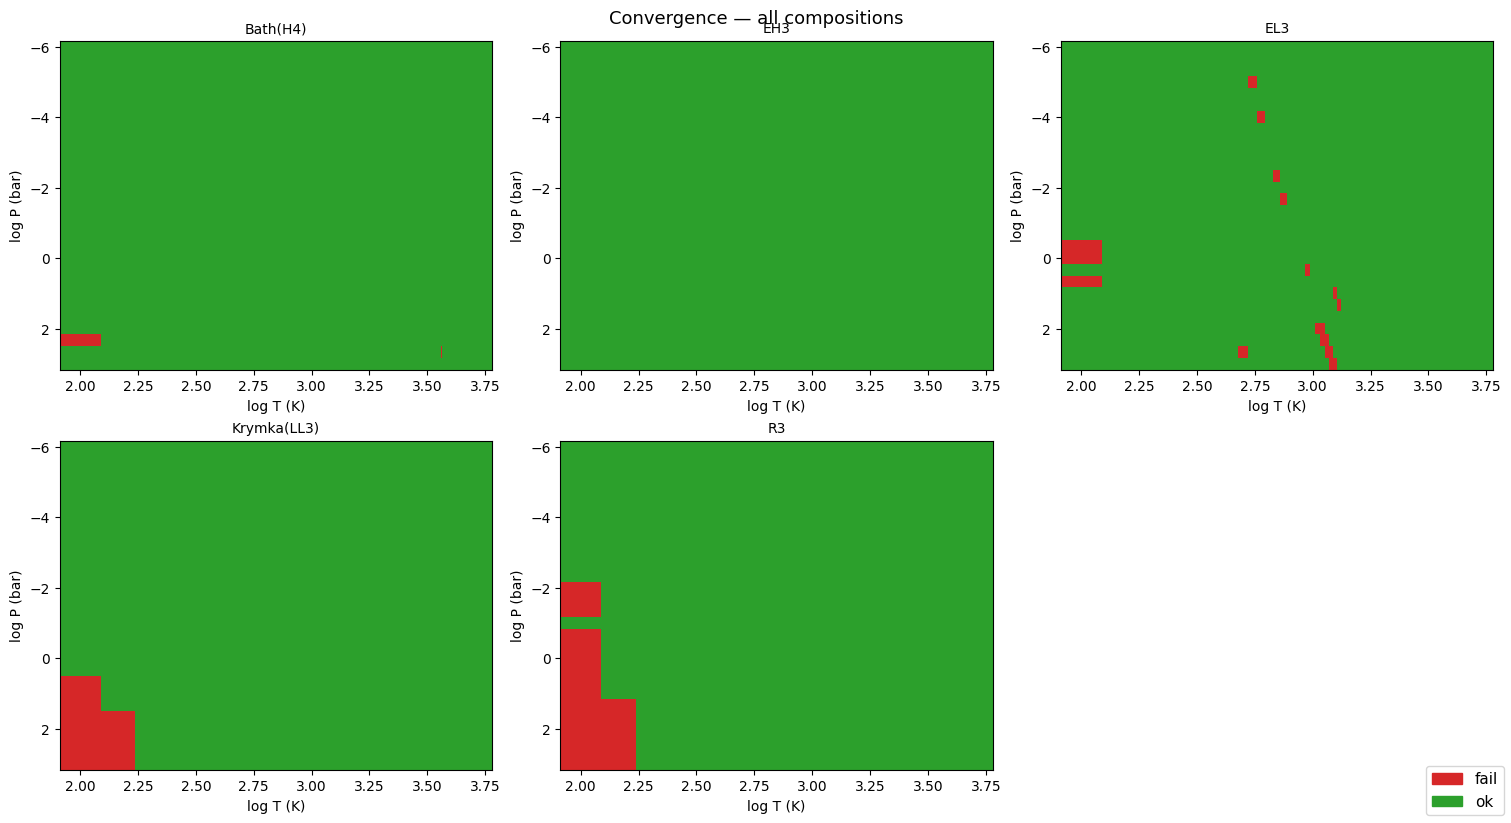

In [12]:
def plot_boolean_grid(data, value_col, title_prefix, cmap=None, legend_labels=None):
    """Plot a binary (True/False) status on the T-P grid for all compositions."""
    n = len(data)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    _cmap = cmap or mcolors.ListedColormap(["#d62728", "#2ca02c"])  # red=fail, green=ok

    for ax, (comp, df) in zip(axes, data.items()):
        T_vals, P_vals, grid = to_grid(df, value_col)
        im = ax.pcolormesh(
            np.log10(T_vals), np.log10(P_vals), grid.astype(float).T,
            cmap=_cmap, vmin=0, vmax=1, shading="nearest"
        )
        ax.set_title(comp, fontsize=10)
        ax.set_xlabel("log T (K)")
        ax.set_ylabel("log P (bar)")
        ax.invert_yaxis()

    for ax in axes[n:]:
        ax.set_visible(False)

    labels = legend_labels or ["fail", "ok"]
    patches = [Patch(color="#d62728", label=labels[0]),
               Patch(color="#2ca02c", label=labels[1])]
    fig.legend(handles=patches, loc="lower right", fontsize=11)
    fig.suptitle(f"{title_prefix} — all compositions", fontsize=13, y=1.01)
    plt.show()


plot_boolean_grid(monitor_data, "converged", "Convergence")

## 2. Element Conservation

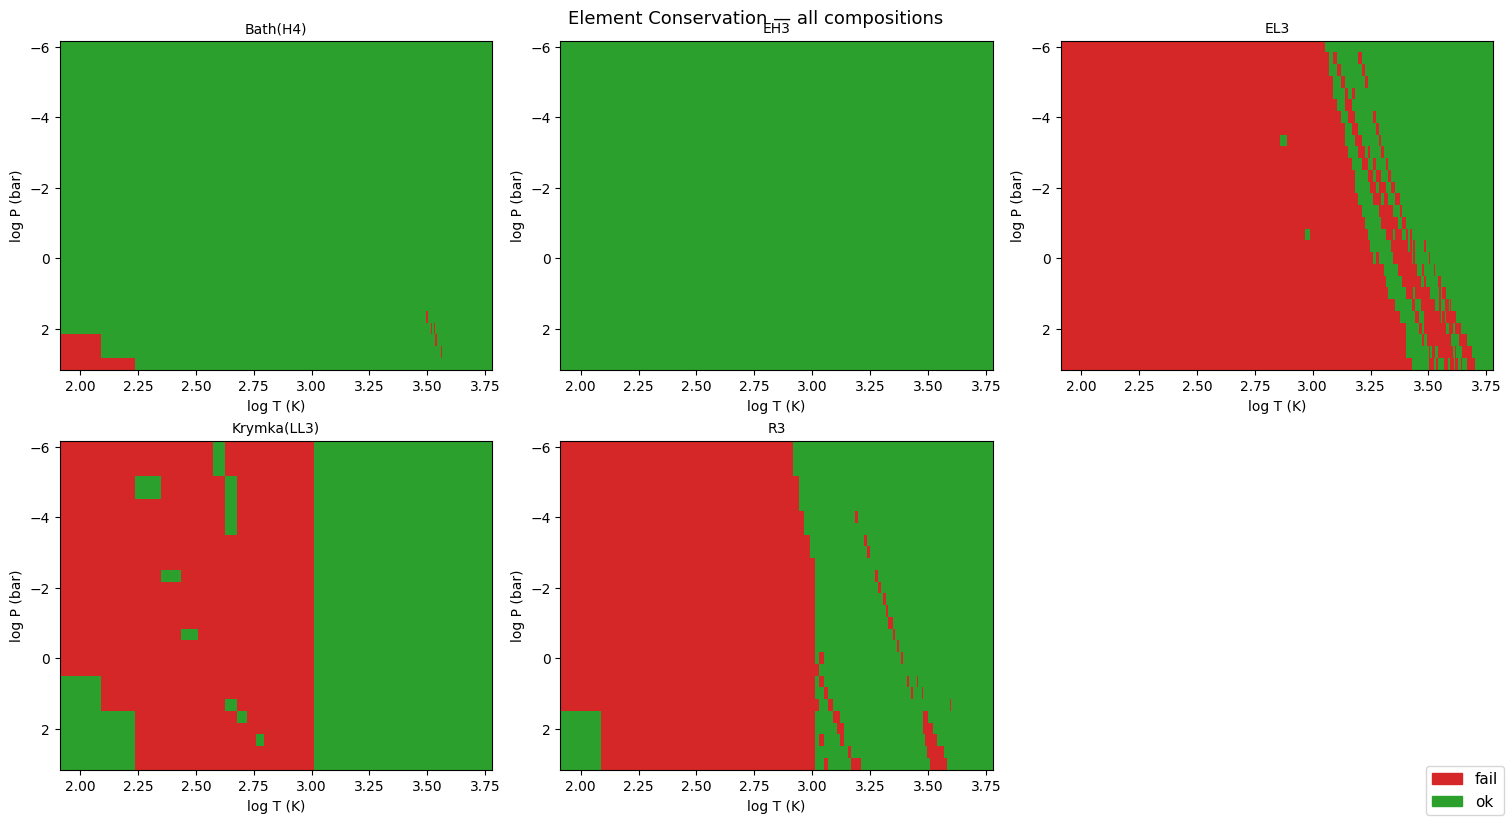

In [13]:
plot_boolean_grid(monitor_data, "elem_conserved", "Element Conservation")

## 3. Number of Elements Failing Conservation

At each grid point, count how many individual elements failed conservation.

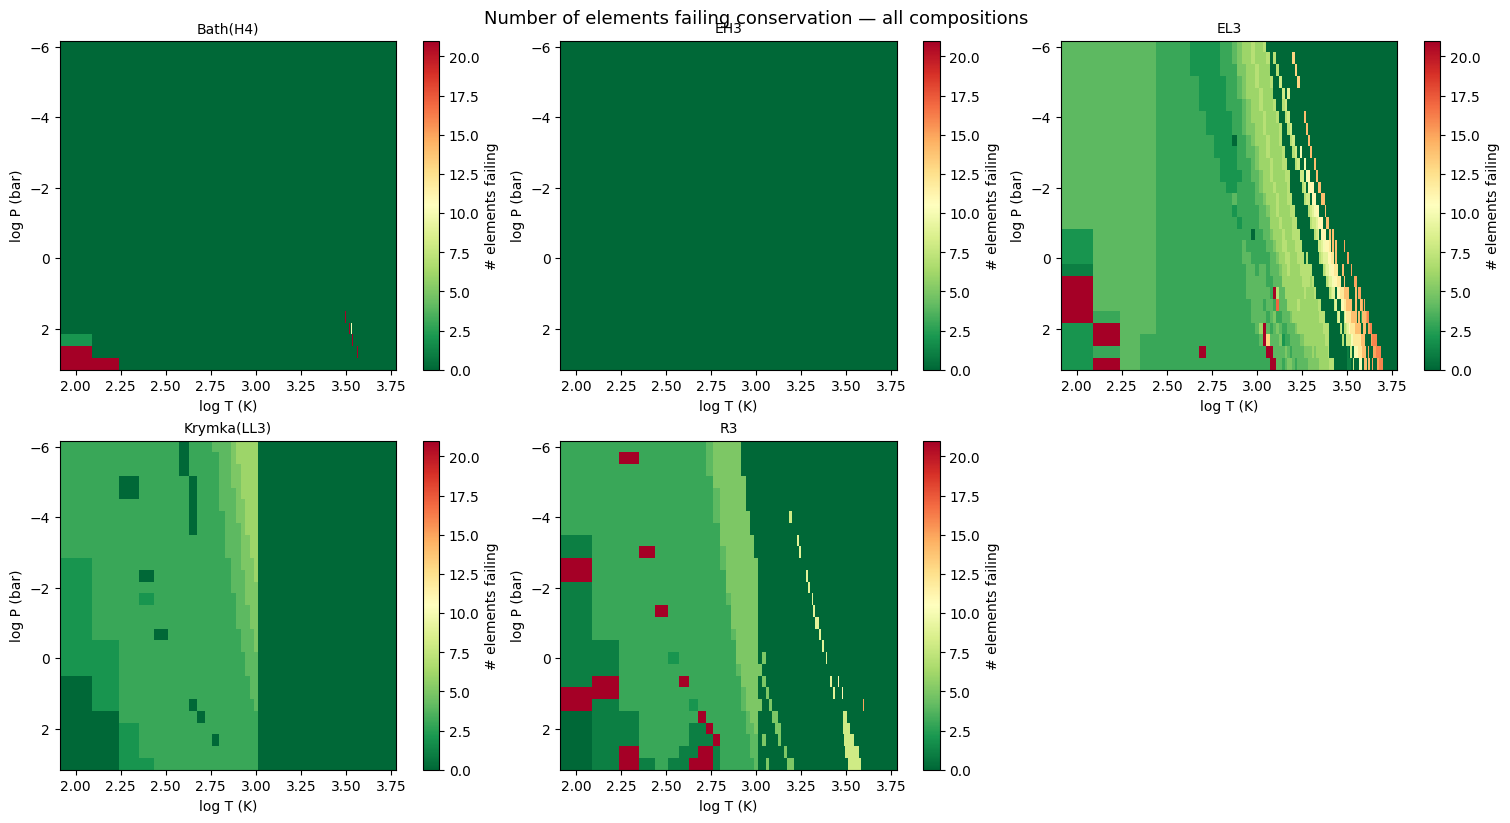

In [14]:
def add_n_failing(data, element_cols):
    """Add a column counting how many elements failed conservation."""
    for comp, df in data.items():
        cols = [c for c in element_cols if c in df.columns]
        # cols are bool: True=ok, so failing = ~ok
        df["n_elem_failing"] = (~df[cols]).sum(axis=1)

add_n_failing(monitor_data, ELEMENT_COLS)

n = len(monitor_data)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()

max_fail = max(
    df["n_elem_failing"].max() for df in monitor_data.values()
)

for ax, (comp, df) in zip(axes, monitor_data.items()):
    T_vals, P_vals, grid = to_grid(df, "n_elem_failing")
    im = ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), grid.T,
        cmap="RdYlGn_r", vmin=0, vmax=max_fail, shading="nearest"
    )
    ax.invert_yaxis()
    plt.colorbar(im, ax=ax, label="# elements failing")
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Number of elements failing conservation — all compositions", fontsize=13, y=1.01)
plt.show()

## 4. Iteration Count

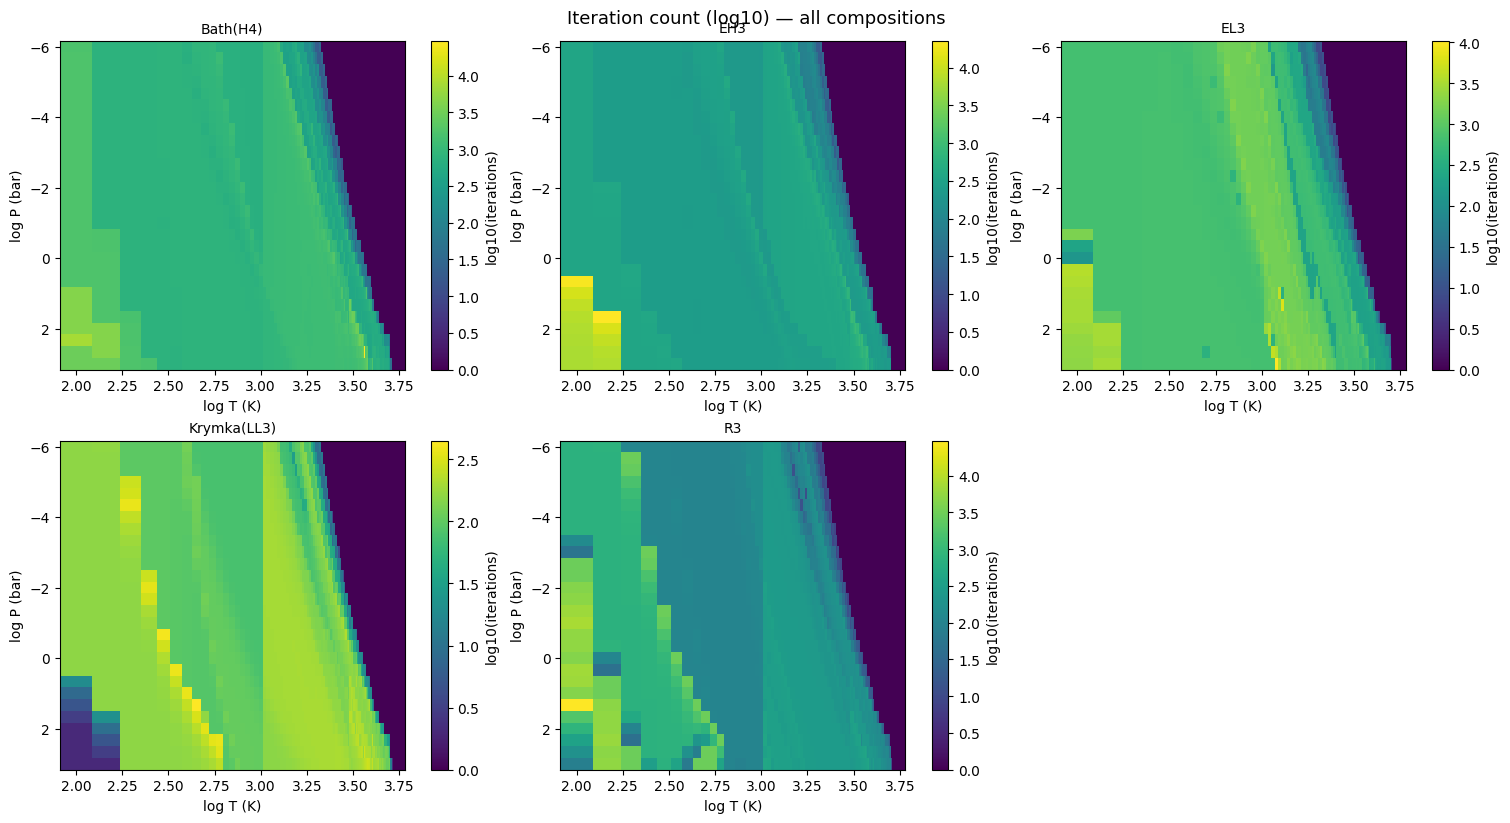

In [15]:
n = len(monitor_data)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()

for ax, (comp, df) in zip(axes, monitor_data.items()):
    T_vals, P_vals, grid = to_grid(df, "iterations")
    im = ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), np.log10(grid.clip(1)).T,
        cmap="viridis", shading="nearest"
    )
    plt.colorbar(im, ax=ax, label="log10(iterations)")
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")
    ax.invert_yaxis()

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Iteration count (log10) — all compositions", fontsize=13, y=1.01)
plt.show()

## 5. Combined Status Map

Three-state map: converged + element conservation ok (green), converged but element conservation failed (yellow), not converged (red).

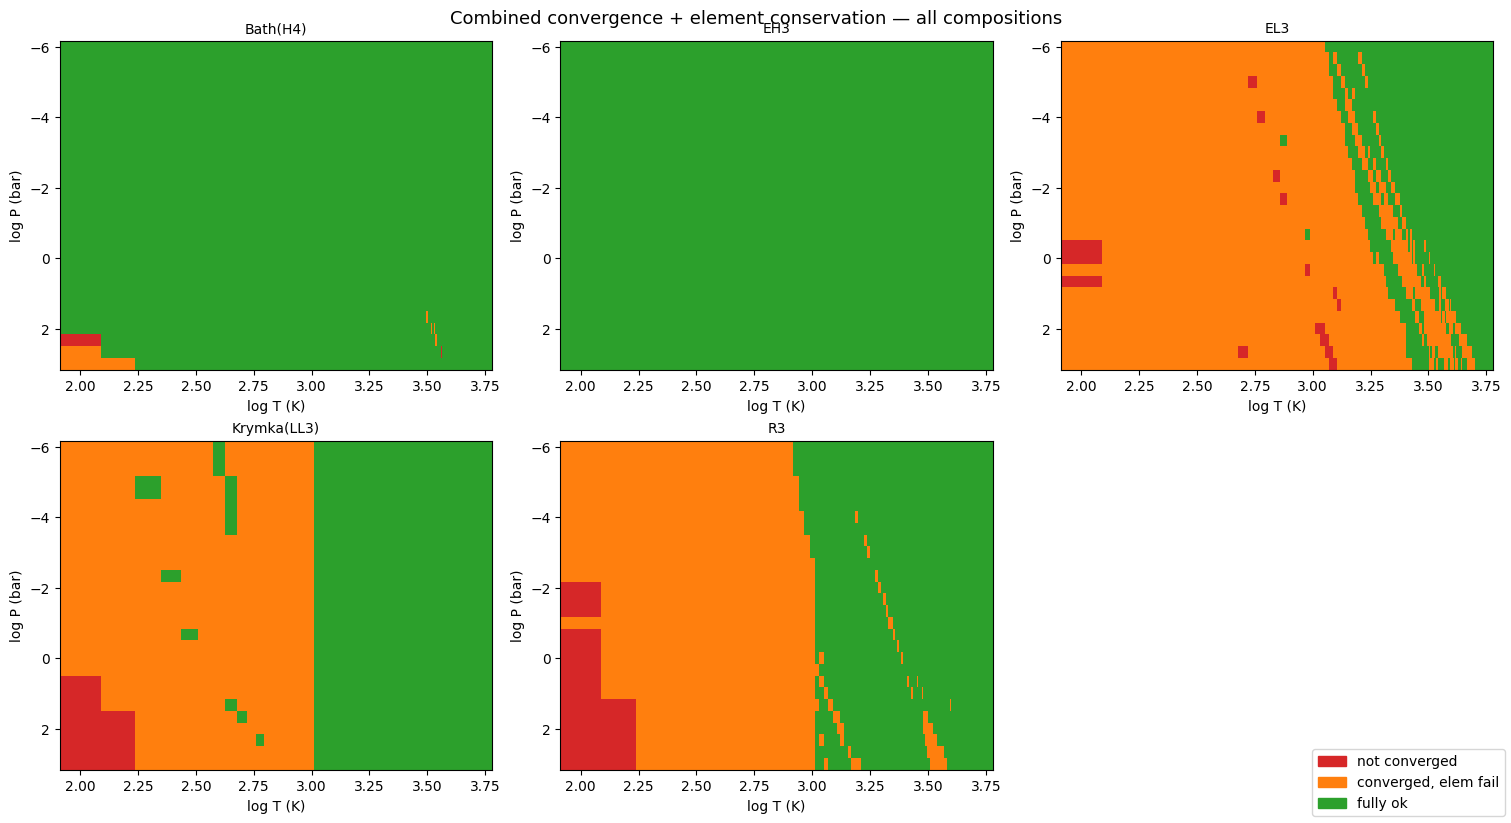

In [16]:
def combined_status(df):
    """0 = not converged, 1 = converged but elem fail, 2 = fully ok."""
    status = np.zeros(len(df), dtype=int)
    status[df["converged"]] = 1
    status[df["converged"] & df["elem_conserved"]] = 2
    return status


status_cmap = mcolors.ListedColormap(["#d62728", "#ff7f0e", "#2ca02c"])
status_labels = ["not converged", "converged, elem fail", "fully ok"]
status_colors = ["#d62728", "#ff7f0e", "#2ca02c"]

n = len(monitor_data)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()

for ax, (comp, df) in zip(axes, monitor_data.items()):
    df["_status"] = combined_status(df)
    T_vals, P_vals, grid = to_grid(df, "_status")
    ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), grid.T,
        cmap=status_cmap, vmin=0, vmax=2, shading="nearest"
    )
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")
    ax.invert_yaxis()

for ax in axes[n:]:
    ax.set_visible(False)

patches = [Patch(color=c, label=l) for c, l in zip(status_colors, status_labels)]
fig.legend(handles=patches, loc="lower right", fontsize=10)
fig.suptitle("Combined convergence + element conservation — all compositions", fontsize=13, y=1.01)
plt.show()

## 6. Mean Molecular Weight

Mean molecular weight `m(u)` across the T-P grid for each composition.

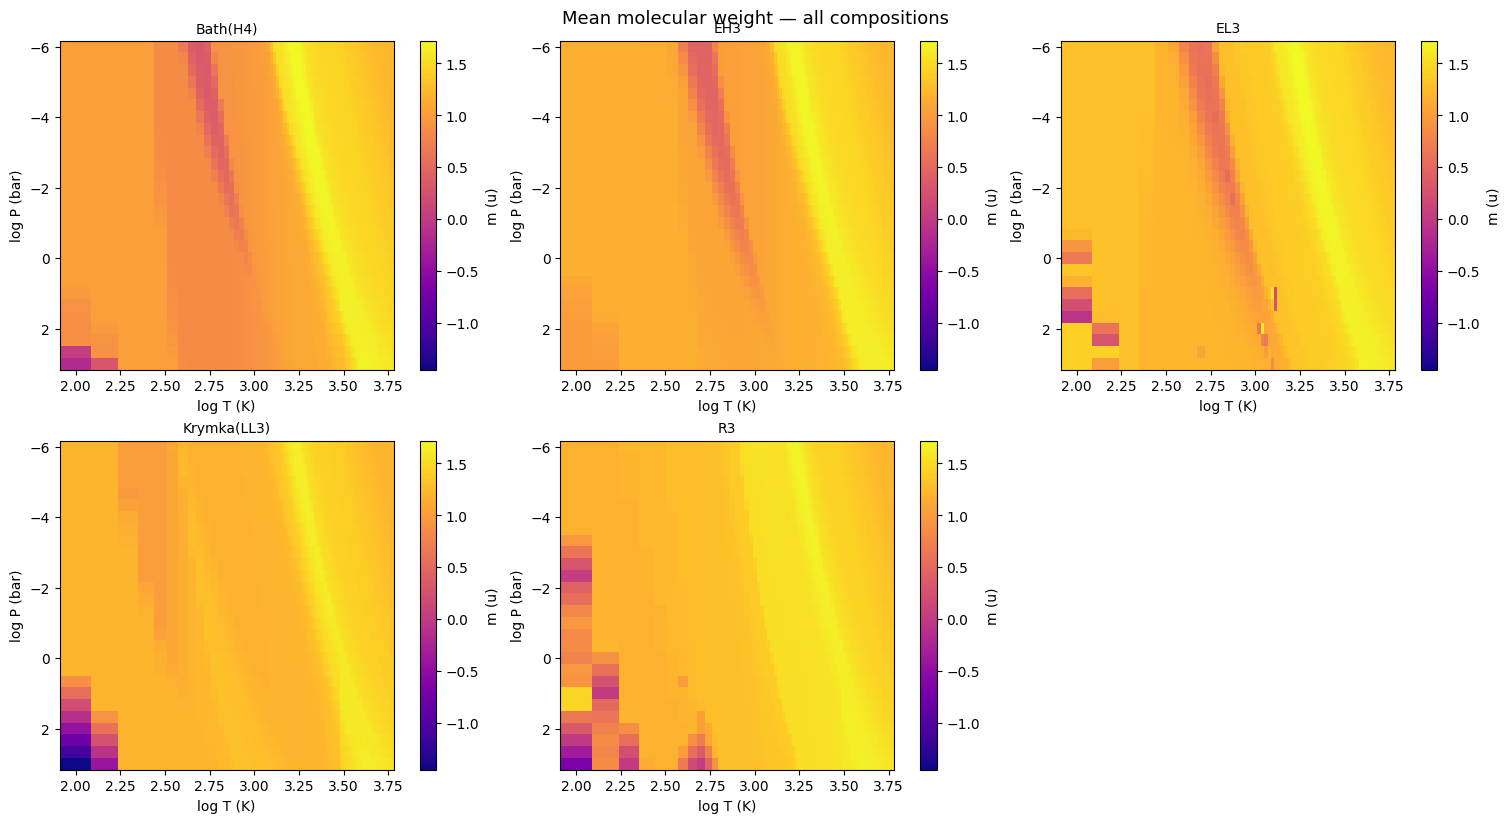

In [17]:
n = len(monitor_data)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.array(axes).flatten()

vmin = min(np.log10(df["m_u"].min()) for df in monitor_data.values())
vmax = max(np.log10(df["m_u"].max()) for df in monitor_data.values())

for ax, (comp, df) in zip(axes, monitor_data.items()):
    T_vals, P_vals, grid = to_grid(df, "m_u")
    im = ax.pcolormesh(
        np.log10(T_vals), np.log10(P_vals), np.log10(grid.T),
        cmap="plasma", vmin=vmin, vmax=vmax, shading="nearest"
    )
    plt.colorbar(im, ax=ax, label="m (u)")
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("log T (K)")
    ax.set_ylabel("log P (bar)")
    ax.invert_yaxis()

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Mean molecular weight — all compositions", fontsize=13, y=1.01)
plt.show()